# 02 — Spatial–Affective Correspondences: Audit and Re-estimation

MallWorld audit (2026-10)

---

## Scope

This notebook re-derives every environmental "correspondence" in two reports, *Correspondential Structure in Collective Dream Space* (§3) and *Vertical World Structure in MallWorld Dreams*, plus the location–atmosphere results of *Emergent Structure in Recurring Dream Environments*. For each claim it gives:
1. **Old**: the reported figure, and where possible a reproduction of how it was computed.
2. **Corrected**: the primary population (1,918 dream reports), dream-clustered inference, adjustment for narrative length, and location type controlled or intrinsically vertical types removed where the coding requires it.
3. **Verdict** against the framework prediction as it was stated.

**Outcome variable.** The schema's ten atmosphere categories are collapsed by the loader into a valence: negative = threatening, oppressive, uncomfortable, wrong, eerie, chaotic; neutral; positive = welcoming, peaceful. "Nostalgic" is ambiguous and left out. The archived notebooks used two different 5-point mappings; both are reproduced where needed.

**Framework predictions under test.** These are taken from Swedenborg as the archived notebooks stated them:
- **Elevation:** heavens are above, hells below (*Heaven and Hell* §§188, 584), so atmosphere should improve with height.
- **Water:** clear water corresponds to truth, turbid water to falsity.
- **Light:** light corresponds to wisdom and heat to love; light without heat is truth without good.
- **Cleanliness and filth:** filth corresponds to impure loves.
- **Exposure:** nakedness without shame belongs to innocence, exposure with shame to its loss.

In [1]:
import sys, json, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2_contingency, spearmanr, fisher_exact
from statsmodels.stats.multitest import multipletests

MW_ROOT = Path.cwd().parent
sys.path.insert(0, str(MW_ROOT / "scripts"))
import mallworld_dataset as mw  # verified loader: schema-checked fields, populations, cluster keys

OUTPUT_DIR = MW_ROOT / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

posts = mw.load_posts()
primary = posts[posts["primary"]].copy()
print(f"Posts: {len(posts):,} | primary dream reports: {len(primary):,} from {primary['author'].nunique():,} authors")

import statsmodels.formula.api as smf
from statsmodels.discrete.conditional_models import ConditionalLogit

L = mw.load_locations()                          # primary population
Lx = mw.load_locations("extractable")            # thesis population, for reproductions only
L["neg"] = (L["valence"] == -1).astype(float).where(L["valence"].notna())
L["pos"] = (L["valence"] == 1).astype(float).where(L["valence"].notna())
L["level_cat"] = pd.cut(L["vertical_level"], [-3, -0.5, 0.5, 3], labels=["underground", "ground", "elevated"])
top_types = L["location_type"].value_counts()
L["type_c"] = L["location_type"].where(L["location_type"].map(top_types) >= 40, "rare_type")
print(f"Primary locations: {len(L):,}; with valence: {L['valence'].notna().sum():,}; with vertical level: {L['vertical_level'].notna().sum():,}; "
      f"with both: {(L['valence'].notna() & L['vertical_level'].notna()).sum():,} in {L.loc[L['valence'].notna() & L['vertical_level'].notna(), 'post_id'].nunique():,} dreams")

def cluster_prop(df, y, cluster="post_id"):
    """Proportion with a cluster-robust (ratio-estimator) 95% CI."""
    d = df.dropna(subset=[y])
    n = len(d)
    if n == 0:
        return np.nan, np.nan, np.nan, 0, 0
    p = d[y].mean()
    tot = d.groupby(cluster)[y].agg(["sum", "size"])
    C = len(tot)
    var = (((tot["sum"] - p * tot["size"]) ** 2).sum() * C / max(C - 1, 1)) / n ** 2
    se = np.sqrt(var)
    return p, max(p - 1.96 * se, 0), min(p + 1.96 * se, 1), n, C

def rate_by(df, group, y, order=None):
    rows = []
    for g in (order or sorted(df[group].dropna().unique())):
        p, lo, hi, n, C = cluster_prop(df[df[group] == g], y)
        rows.append({group: g, "n locations": n, "dreams": C, "%": 100 * p, "95% CI": f"{100 * lo:.1f}–{100 * hi:.1f}"})
    return pd.DataFrame(rows).set_index(group)

def fast_cluster_boot(df, stat, cluster="post_id", n_boot=1000, seed=0):
    idx = df.groupby(cluster).indices
    keys = list(idx)
    rng = np.random.default_rng(seed)
    vals = []
    for _ in range(n_boot):
        pick = rng.integers(0, len(keys), len(keys))
        rows = np.concatenate([idx[keys[i]] for i in pick])
        v = stat(df.iloc[rows])
        if np.isfinite(v):
            vals.append(v)
    return np.percentile(vals, [2.5, 97.5])

def clogit(df, formula, cluster="post_id"):
    res = mw.clustered_logit(df, formula, cluster)
    return res

def fmt_or(res, term):
    t = mw.odds_ratio_table(res, [term]).iloc[0]
    return f"OR {t.OR:.2f} [{t.lo:.2f}–{t.hi:.2f}], p = {t.p:.2g}"

Posts: 3,732 | primary dream reports: 1,918 from 1,303 authors


Primary locations: 8,685; with valence: 4,145; with vertical level: 2,983; with both: 1,605 in 667 dreams


## C1 — Vertical position and atmosphere

**Old claims.** Three different values were reported for the same relation:
- thesis: "ρ = 0.25–0.30, p < 0.0001, replicated across train/validation/test splits";
- vertical report: "ρ = 0.12"; "underground 2.27 vs ground 2.73 vs elevated 2.77"; "χ² = 143.1, df = 15";
- archived notebook 09, the "pre-registered" H1: ρ = +0.055.

In [2]:
# Reproduce the archived computations
def old_rho(df, mapping):
    d = df.assign(v=df["vertical"].map(mw.VERTICAL_LEVEL), a=df["atmosphere"].map(mapping)).dropna(subset=["v", "a"])
    return spearmanr(d["v"], d["a"]), len(d)
(r9, p9), n9 = old_rho(Lx, mw.ATMOSPHERE_OLD_5PT)
print(f"Notebook 09 H1 reproduced (thesis population, 5-point map): rho = {r9:+.4f}, p = {p9:.3g}, n = {n9:,}")
map07 = {"threatening": 1, "uncomfortable": 2, "oppressive": 2, "neutral": 3, "peaceful": 4, "welcoming": 5}  # omits eerie, chaotic, wrong, nostalgic
(r7, p7), n7 = old_rho(Lx, map07)
print(f"Notebook 07 reproduced (map omitting eerie/chaotic/wrong/nostalgic): rho = {r7:+.4f}, p = {p7:.3g}, n = {n7:,}")
d7 = Lx.assign(v=Lx["vertical"].map(mw.VERTICAL_LEVEL), a=Lx["atmosphere"].map(map07)).dropna(subset=["v", "a"])
d7["cat"] = pd.cut(d7["v"], [-3, -0.5, 0.5, 3], labels=["underground", "ground", "elevated"])
print("  Notebook 07 means:", d7.groupby("cat", observed=True)["a"].mean().round(2).to_dict())
print("The value 0.25-0.30 is not produced by any cell: it appears only in hand-written summary banners of notebook 09.")

# Corrected
V = L.dropna(subset=["valence", "vertical_level"])
rho_v, p_v = spearmanr(V["vertical_level"], V["valence"])
lo_v, hi_v = fast_cluster_boot(V, lambda d: spearmanr(d["vertical_level"], d["valence"])[0])
print(f"\nCorrected (primary population): Spearman(vertical level, valence) = {rho_v:+.3f}, dream-bootstrap 95% CI {lo_v:+.3f} to {hi_v:+.3f}, n = {len(V):,} locations in {V['post_id'].nunique():,} dreams")
print("\nNegative atmosphere by level (cluster-robust CIs):")
print(rate_by(V.assign(neg=V["neg"]), "level_cat", "neg", ["underground", "ground", "elevated"]).round(1).to_string())
print("\nPositive atmosphere by level:")
print(rate_by(V, "level_cat", "pos", ["underground", "ground", "elevated"]).round(1).to_string())

Notebook 09 H1 reproduced (thesis population, 5-point map): rho = +0.0552, p = 0.014, n = 1,981
Notebook 07 reproduced (map omitting eerie/chaotic/wrong/nostalgic): rho = +0.0674, p = 0.0135, n = 1,342
  Notebook 07 means: {'underground': 2.27, 'ground': 2.73, 'elevated': 2.61}
The value 0.25-0.30 is not produced by any cell: it appears only in hand-written summary banners of notebook 09.



Corrected (primary population): Spearman(vertical level, valence) = +0.064, dream-bootstrap 95% CI +0.007 to +0.114, n = 1,605 locations in 667 dreams

Negative atmosphere by level (cluster-robust CIs):
             n locations  dreams     %     95% CI
level_cat                                        
underground          333     229  76.0  70.3–81.7
ground               810     402  58.3  54.2–62.3
elevated             462     287  65.2  60.1–70.2

Positive atmosphere by level:
             n locations  dreams     %     95% CI
level_cat                                        
underground          333     229   9.6   5.9–13.4
ground               810     402  11.7   9.2–14.2
elevated             462     287  14.9  11.3–18.5


In [3]:
V2 = V.copy()
V2["under"] = (V2["vertical_level"] < 0).astype(int)
V2["elev"] = (V2["vertical_level"] > 0).astype(int)
models = {}
models["A: level dummies"] = clogit(V2, "neg ~ under + elev")
models["B: + log words"] = clogit(V2, "neg ~ under + elev + log_words")
models["C: + location type"] = clogit(V2, "neg ~ under + elev + log_words + C(type_c)")
nv = V2[~V2["intrinsically_vertical"]]
models["D: no intrinsically vertical types"] = clogit(nv, "neg ~ under + elev + log_words")
models["E: D + location type"] = clogit(nv, "neg ~ under + elev + log_words + C(type_c)")
rows = []
for name, res in models.items():
    t = mw.odds_ratio_table(res, ["under", "elev"])
    rows.append({"model": name, "n": int(res.nobs), "underground OR": f"{t.loc['under', 'OR']:.2f} [{t.loc['under', 'lo']:.2f}–{t.loc['under', 'hi']:.2f}]",
                 "p (under)": t.loc["under", "p"], "elevated OR": f"{t.loc['elev', 'OR']:.2f} [{t.loc['elev', 'lo']:.2f}–{t.loc['elev', 'hi']:.2f}]",
                 "p (elev)": t.loc["elev", "p"]})
with pd.option_context("display.float_format", "{:.3g}".format):
    print("Negative atmosphere vs ground level, logistic regression with dream-clustered SEs")
    print(pd.DataFrame(rows).set_index("model").to_string())

# Within-dream: dreams with coded locations at two or more levels
W = V2[V2.groupby("post_id")["vertical_level"].transform("nunique") >= 2]
W = W[W.groupby("post_id")["neg"].transform("nunique") >= 2]
cl = ConditionalLogit(W["neg"], W[["vertical_level"]], groups=W["post_id"]).fit(disp=0)
b, se = cl.params.iloc[0], cl.bse.iloc[0]
print(f"\nWithin-dream conditional logit (dreams that vary in both level and valence: {W['post_id'].nunique()} dreams, {len(W)} locations):")
print(f"  OR per level up for a negative atmosphere = {np.exp(b):.2f} [{np.exp(b - 1.96 * se):.2f}–{np.exp(b + 1.96 * se):.2f}], p = {cl.pvalues.iloc[0]:.2g}")

/usr/local/lib/python3.11/dist-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


Negative atmosphere vs ground level, logistic regression with dream-clustered SEs
                                       n    underground OR  p (under)       elevated OR  p (elev)
model                                                                                            
A: level dummies                    1605  2.26 [1.62–3.18]   2.13e-06  1.34 [1.04–1.73]    0.0259
B: + log words                      1605  2.29 [1.63–3.23]   2.06e-06  1.35 [1.04–1.74]    0.0245
C: + location type                  1605  1.79 [1.20–2.66]    0.00406  1.35 [1.02–1.80]    0.0388
D: no intrinsically vertical types  1440  1.69 [1.17–2.46]    0.00571  1.32 [1.01–1.71]    0.0417
E: D + location type                1440  1.76 [1.18–2.62]    0.00561  1.29 [0.97–1.71]    0.0845

Within-dream conditional logit (dreams that vary in both level and valence: 111 dreams, 568 locations):
  OR per level up for a negative atmosphere = 0.88 [0.72–1.07], p = 0.19


/usr/local/lib/python3.11/dist-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


### Findings — C1

**Old figures.** The archived computations are reproduced exactly:
- notebook 09 "pre-registered" H1: ρ = +0.055 (thesis population, n = 1,981);
- notebook 07: ρ = +0.067; means 2.27 / 2.73 / **2.61**, with n = 263 / 678 / 401.

The vertical report printed ρ = 0.12, an elevated mean of 2.77 and n = 570 / 1,547 / 819. None of these appears in any notebook output. The thesis's "ρ = 0.25–0.30, replicated across splits" exists only in typed summary banners, and in notebook 09 the effect was not significant in either holdout split. Notebook 07's own output shows the roof level (2.43) below ground (2.73), and the χ² it computed has df = 18, not the reported 15.

**Corrected.** Over 1,605 locations in 667 dreams, the rank correlation between level and valence is **ρ = +0.064** (dream-bootstrap 95% CI 0.007–0.114). The relation is not monotone:

| Level | Negative atmosphere | Positive atmosphere |
|---|---|---|
| Underground | 76.0% (70.3–81.7) | 9.6% |
| Ground | 58.3% (54.2–62.3) | 11.7% |
| Elevated | 65.2% (60.1–70.2) | 14.9% |

Underground locations are more often negative than ground locations. This holds after adjusting for length (OR 2.29), after controlling location type (OR 1.79), and after removing basements, caves, subways, parking structures and generic "underground" types (OR 1.69–1.76). Elevated locations are *also* more often negative than ground (OR 1.29–1.35, p = 0.03–0.08). Within the same dream, moving up does not make the atmosphere better (conditional logit OR 0.88 per level, 95% CI 0.72–1.07, 111 dreams).

**Verdict.**
- **Partial hit:** "below is worse" holds and is not reducible to basements.
- **Miss:** "higher is better" fails, because ground level, not the top, is the least negative.

The archived reports claimed a monotone elevation gradient (ρ 0.25–0.30). The data show a ground-level optimum with a stronger penalty below than above.

## C2 — Water and atmosphere

**Old claims.**
- Archived notebook 09: "Underground 48.1% dirty water vs 18% elsewhere (2.6×, p < 0.0001)". "Dirty" there pooled `pool_dirty`, `flood`, `leak`, `ocean_turbulent`, `tsunami` and `submerged`.
- Thesis §3.2 restates this as *water clarity ↔ atmosphere*: "clean water ≈ 45% positive atmosphere vs dirty ≈ 17%". No cell computes those two percentages.

In [4]:
CLEAN = ["pool_clean", "fountain", "ocean_calm", "river"]
DIRTY = ["pool_dirty", "flood", "leak", "ocean_turbulent", "tsunami", "submerged"]
mw.check_values("water_presence", CLEAN + DIRTY)
Wt = L[L["water_presence"].isin(CLEAN + DIRTY)].copy()
Wt["dirty"] = Wt["water_presence"].isin(DIRTY).astype(float)
print("Water states among primary locations with water:", Wt["water_presence"].value_counts().to_dict())
wv = Wt.dropna(subset=["vertical_level"])
print("\nDirty water by level (as in archived notebook 09, primary population, clustered CIs):")
print(rate_by(wv, "level_cat", "dirty", ["underground", "ground", "elevated"]).round(1).to_string())
print("Underground dirty water by type:", wv[wv["vertical_level"] < 0].groupby("location_type")["dirty"].agg(["sum", "size"]).sort_values("size", ascending=False).head(6).to_dict("index"))
res = clogit(wv.assign(under=(wv["vertical_level"] < 0).astype(int)), "dirty ~ under + log_words")
print("Dirty water, underground vs not:", fmt_or(res, "under"))
nvw = wv[~wv["intrinsically_vertical"]]
res2 = clogit(nvw.assign(under=(nvw["vertical_level"] < 0).astype(int)), "dirty ~ under + log_words")
print("  excluding intrinsically vertical types:", fmt_or(res2, "under"), f"(n = {len(nvw)}, underground n = {int((nvw['vertical_level'] < 0).sum())})")

wa = Wt.dropna(subset=["valence"])
print("\nThe thesis claim (water state x atmosphere), computed for the first time:")
print(rate_by(wa.assign(state=np.where(wa["dirty"] == 1, "dirty", "clean")), "state", "pos").round(1).to_string())
print(rate_by(wa.assign(state=np.where(wa["dirty"] == 1, "dirty", "clean")), "state", "neg").round(1).to_string())
res3 = clogit(wa, "neg ~ dirty + log_words")
print("Negative atmosphere, dirty vs clean water:", fmt_or(res3, "dirty"))
res4 = clogit(wa, "neg ~ dirty + log_words + C(type_c)")
print("  + location type:", fmt_or(res4, "dirty"))
DANGER = ["flood", "tsunami", "ocean_turbulent"]
wa_nd = wa[~wa["water_presence"].isin(DANGER)]
print(f"  excluding dangerous water events (flood, tsunami, turbulent ocean): dirty n = {int(wa_nd['dirty'].sum())}, clean n = {int((wa_nd['dirty'] == 0).sum())};",
      fmt_or(clogit(wa_nd, "neg ~ dirty + log_words"), "dirty"))

# Clarity proper: the free-text water_clarity field, keyword-classified
wc = L["water_clarity"].fillna("").str.lower()
clear_kw = wc.str.contains(r"\b(?:clear|crystal|clean|pristine|transparent|turquoise|sparkl)") & ~wc.str.contains(r"unclear|not clear")
murky_kw = wc.str.contains(r"\b(?:murky|muddy|mud|dirty|stagnant|brown|black|dark|filthy|polluted|cloudy|sewage|slim|gross|toxic|oily|scum)")
Lc = L.assign(clarity=np.select([clear_kw & ~murky_kw, murky_kw & ~clear_kw], ["clear", "murky"], "unclassified"))
cl = Lc[Lc["clarity"] != "unclassified"].dropna(subset=["valence"])
print(f"\nFree-text clarity: clear {int((Lc['clarity'] == 'clear').sum())}, murky {int((Lc['clarity'] == 'murky').sum())} locations; with valence: {len(cl)}")
print(rate_by(cl, "clarity", "neg").round(1).to_string())
tab_c = pd.crosstab(cl["clarity"], cl["neg"])
print("  Fisher exact (clear vs murky x negative):", fisher_exact(tab_c.values), "(clusters: {} dreams)".format(cl["post_id"].nunique()))

Water states among primary locations with water: {'river': 188, 'ocean_calm': 182, 'pool_clean': 165, 'fountain': 60, 'ocean_turbulent': 55, 'flood': 46, 'leak': 34, 'submerged': 15, 'pool_dirty': 14, 'tsunami': 8}

Dirty water by level (as in archived notebook 09, primary population, clustered CIs):
             n locations  dreams     %     95% CI
level_cat                                        
underground           72      58  52.8  38.9–66.6
ground               215     149  18.1  12.3–24.0
elevated              74      60  23.0  12.2–33.8
Underground dirty water by type: {'other': {'sum': 5.0, 'size': 13}, 'underground': {'sum': 8.0, 'size': 10}, 'cave': {'sum': 5.0, 'size': 9}, 'pool': {'sum': 0.0, 'size': 8}, 'basement': {'sum': 5.0, 'size': 5}, 'restaurant': {'sum': 4.0, 'size': 4}}
Dirty water, underground vs not: OR 4.89 [2.54–9.41], p = 2e-06
  excluding intrinsically vertical types: OR 3.26 [1.47–7.23], p = 0.0037 (n = 325, underground n = 47)

The thesis claim (water sta

  + location type: OR 9.58 [4.30–21.36], p = 3.3e-08
  excluding dangerous water events (flood, tsunami, turbulent ocean): dirty n = 56, clean n = 279; OR 6.93 [2.99–16.02], p = 6.1e-06

Free-text clarity: clear 51, murky 33 locations; with valence: 60
         n locations  dreams     %     95% CI
clarity                                      
clear             34      29  20.6   3.6–37.6
murky             26      23  73.1  54.3–91.9
  Fisher exact (clear vs murky x negative): SignificanceResult(statistic=np.float64(10.46938775510204), pvalue=np.float64(6.661138160024826e-05)) (clusters: 50 dreams)


/usr/local/lib/python3.11/dist-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


### Findings — C2

**Old.** "Underground 48.1% dirty water vs 18%" reproduces in direction on the primary population (52.8% vs 18.1% at ground and 23.0% elevated; OR 4.89; OR 3.26 without intrinsically vertical types). The thesis's water-clarity × atmosphere figures ("45% vs 17% positive") were never computed.

**Computed for the first time**, the water–atmosphere association is strong:
- **Positive atmosphere:** 37.6% where the water is clean, 7.4% where it is dirty.
- **Negative atmosphere:** 43.0% clean vs 84.4% dirty (OR 7.19; 9.58 with location type).
- **Danger is not the explanation.** It holds without floods, tsunamis and turbulent sea (OR 6.93).
- **Clarity in the free-text field:** clear water 20.6% negative vs murky 73.1% (Fisher OR 10.5, p = 7 × 10⁻⁵; 60 locations in 50 dreams).

**Verdict.** **Hit at the level of pattern fit**: water described as clear goes with benign atmospheres and turbid water with negative ones, as the correspondence of water to truth predicts. The association is equally expected from ordinary associations ("murky water is unpleasant"), so it does not discriminate between the framework and a cultural reading.

## C3 — Light and atmosphere

**Old claims.**
- Thesis §3.3: "light quality × atmosphere χ² = 182.18, V = 0.483, ρ = 0.353; bright/natural 29% negative … dark/absent 79%; discordant states 2.7%".
- Archived notebook 09 Pattern 4: "warm light above vs cold below ✓ correct (41.9% vs 60–69.5% warm), ~1.5×, Strong". No test was computed.

The framework's own marker is light **temperature**: heat corresponds to love, and light without heat to truth without good. Light quality (bright/dim/dark) and atmosphere are both coded from the same descriptive sentence ("dark and eerie"), so their association is partly the coder reading one sentence twice.

In [5]:
LQ_ORDER = {"bright_natural": 0, "bright_artificial": 1, "mixed": 1, "colored": 1, "dim": 2, "flickering": 2, "dark": 3, "absent": 3}
lq = L[L["light"].isin(list(LQ_ORDER))].dropna(subset=["valence"]).copy()
lq["light_rank"] = lq["light"].map(LQ_ORDER)
lq["light_grp"] = lq["light_rank"].map({0: "bright/natural", 1: "artificial/mixed/colored", 2: "dim/flickering", 3: "dark/absent"})
print("Negative atmosphere by light quality (primary, clustered CIs):")
print(rate_by(lq, "light_grp", "neg", ["bright/natural", "artificial/mixed/colored", "dim/flickering", "dark/absent"]).round(1).to_string())
rho_l = spearmanr(lq["light_rank"], lq["valence"])[0]
lo_l, hi_l = fast_cluster_boot(lq, lambda d: spearmanr(d["light_rank"], d["valence"])[0])
tab = pd.crosstab(lq["light_grp"], lq["valence"])
print(f"Spearman(darkness rank, valence) = {rho_l:+.3f} [{lo_l:+.3f}, {hi_l:+.3f}]; Cramer's V (4x3) = {mw.cramers_v(tab):.3f}; n = {len(lq)} in {lq['post_id'].nunique()} dreams")
print("(Thesis: V = 0.483 on n = 780 — V depends on table shape; the archived table used the thesis population and finer categories.)")
res = clogit(lq, "neg ~ light_rank + log_words + C(type_c)")
print("Negative atmosphere per step darker, + length + location type:", fmt_or(res, "light_rank"))

lt = L[L["light_temperature"].isin(["warm_golden", "cold_white"])].copy()
lt["cold"] = (lt["light_temperature"] == "cold_white").astype(float)
print(f"\nLight temperature coded warm/cold for {len(lt)} locations in {lt['post_id'].nunique()} dreams")
ltv = lt.dropna(subset=["vertical_level"])
print("Warm light share by level (archived Pattern 4, primary population):")
print(rate_by(ltv.assign(warm=1 - ltv["cold"]), "level_cat", "warm", ["underground", "ground", "elevated"]).round(1).to_string())
lta = lt.dropna(subset=["valence"])
print("\nNegative atmosphere: cold vs warm light (the framework's marker):")
print(rate_by(lta.assign(temp=np.where(lta["cold"] == 1, "cold_white", "warm_golden")), "temp", "neg").round(1).to_string())
print("  cold vs warm:", fmt_or(clogit(lta, "neg ~ cold + log_words"), "cold"), "|  + location type:", fmt_or(clogit(lta, "neg ~ cold + log_words + C(type_c)"), "cold"))

Negative atmosphere by light quality (primary, clustered CIs):
                          n locations  dreams     %     95% CI
light_grp                                                     
bright/natural                    229     149  26.2  19.6–32.8
artificial/mixed/colored          486     328  57.0  52.0–62.0
dim/flickering                    259     196  82.2  76.9–87.6
dark/absent                       286     215  94.8  92.1–97.4


Spearman(darkness rank, valence) = -0.489 [-0.533, -0.442]; Cramer's V (4x3) = 0.356; n = 1260 in 662 dreams
(Thesis: V = 0.483 on n = 780 — V depends on table shape; the archived table used the thesis population and finer categories.)
Negative atmosphere per step darker, + length + location type: OR 3.94 [3.21–4.85], p = 5.3e-39

Light temperature coded warm/cold for 586 locations in 374 dreams
Warm light share by level (archived Pattern 4, primary population):
             n locations  dreams     %     95% CI
level_cat                                        
underground           60      45  41.7  27.2–56.1
ground               111      88  67.6  58.5–76.6
elevated              81      65  55.6  43.7–67.5

Negative atmosphere: cold vs warm light (the framework's marker):
             n locations  dreams     %     95% CI
temp                                             
cold_white           233     168  70.8  64.3–77.3
warm_golden          242     173  33.1  26.6–39.5


  cold vs warm: OR 4.88 [3.22–7.40], p = 8.7e-14 |  + location type: OR 5.09 [3.08–8.41], p = 2.2e-10


/usr/local/lib/python3.11/dist-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.11/dist-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


### Findings — C3

**Light quality.** Darker light goes with a worse atmosphere in a steep, monotone gradient:

| Light | Negative atmosphere |
|---|---|
| Bright/natural | 26.2% |
| Artificial/mixed | 57.0% |
| Dim/flickering | 82.2% |
| Dark/absent | 94.8% |

The rank correlation is ρ = −0.49 (95% CI −0.53 to −0.44), OR 3.94 per step darker after length and location type, V = 0.36 on the 4 × 3 table. The thesis's V = 0.483 came from a different table shape and population. Light and atmosphere are usually coded from the same sentence, so part of this association is one description read twice.

**Light temperature**, the framework's own marker (heat = love). Atmosphere is negative in 70.8% of locations under cold white light and 33.1% under warm golden light (OR 4.88; 5.09 with location type). This is a **hit at the level of pattern fit**. The prompt told the coder that warm light "indicates Charity/Good", so the coding was primed (notebook 01, D5).

**Light temperature by level** (archived Pattern 4): warm light is 41.7% underground, 67.6% at ground and 55.6% elevated. It is *less* warm above ground than at ground. The archived summary marked this "✓ correct, Strong" without a test. It is a **miss** for "warm above, cold below", and the same ground-level optimum as C1.

## C4 — Cleanliness, height and atmosphere

**Old claim.** Thesis §3.4: "Cleanliness correlates with vertical position (ρ = 0.302, p < 0.0001); underground 2.15 vs elevated 3.30".

In [6]:
CLEAN_RANK = {"disgusting": 0, "filthy": 1, "dirty": 2, "normal": 3, "clean": 4, "sterile": 5}
C = L[L["cleanliness"].isin(list(CLEAN_RANK))].copy()
C["clean_rank"] = C["cleanliness"].map(CLEAN_RANK)
C["dirty"] = (C["clean_rank"] <= 2).astype(float)
cv = C.dropna(subset=["vertical_level"])
r = spearmanr(cv["vertical_level"], cv["clean_rank"])[0]
lo, hi = fast_cluster_boot(cv, lambda d: spearmanr(d["vertical_level"], d["clean_rank"])[0])
print(f"Spearman(level, cleanliness) = {r:+.3f} [{lo:+.3f}, {hi:+.3f}], n = {len(cv)} in {cv['post_id'].nunique()} dreams")
print(rate_by(cv, "level_cat", "dirty", ["underground", "ground", "elevated"]).round(1).to_string())
print("Underground dirty/filthy/disgusting by type:", cv[cv["vertical_level"] < 0].groupby("location_type")["dirty"].agg(["sum", "size"]).sort_values("size", ascending=False).head(6).to_dict("index"))
nvc = cv[~cv["intrinsically_vertical"]]
r2 = spearmanr(nvc["vertical_level"], nvc["clean_rank"])[0]
lo2, hi2 = fast_cluster_boot(nvc, lambda d: spearmanr(d["vertical_level"], d["clean_rank"])[0])
print(f"Excluding intrinsically vertical types: rho = {r2:+.3f} [{lo2:+.3f}, {hi2:+.3f}], n = {len(nvc)}")
print("Dirty, underground vs not, + length + type:", fmt_or(clogit(cv.assign(under=(cv['vertical_level'] < 0).astype(int)), "dirty ~ under + log_words + C(type_c)"), "under"))
ca = C.dropna(subset=["valence"])
print("\nNegative atmosphere by cleanliness:")
print(rate_by(ca.assign(c=np.where(ca["dirty"] == 1, "dirty/filthy/disgusting", "normal/clean/sterile")), "c", "neg").round(1).to_string())
print("  dirty vs clean:", fmt_or(clogit(ca, "neg ~ dirty + log_words + C(type_c)"), "dirty"))

Spearman(level, cleanliness) = +0.238 [+0.099, +0.359], n = 277 in 185 dreams
             n locations  dreams     %     95% CI
level_cat                                        
underground           88      67  63.6  52.1–75.1
ground               121      92  49.6  40.0–59.2
elevated              68      53  30.9  19.0–42.7
Underground dirty/filthy/disgusting by type: {'other': {'sum': 8.0, 'size': 14}, 'underground': {'sum': 10.0, 'size': 13}, 'basement': {'sum': 11.0, 'size': 12}, 'cave': {'sum': 7.0, 'size': 7}, 'mall_store': {'sum': 2.0, 'size': 6}, 'mall': {'sum': 2.0, 'size': 5}}


Excluding intrinsically vertical types: rho = +0.111 [-0.034, +0.250], n = 236
Dirty, underground vs not, + length + type: OR 1.02 [0.40–2.62], p = 0.97

Negative atmosphere by cleanliness:
                         n locations  dreams     %     95% CI
c                                                            
dirty/filthy/disgusting          261     192  95.4  92.8–98.0
normal/clean/sterile             317     213  34.4  28.4–40.3
  dirty vs clean: OR 39.67 [18.71–84.09], p = 7.9e-22


/usr/local/lib/python3.11/dist-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.11/dist-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


### Findings — C4

**Old:** cleanliness ↔ vertical position ρ = 0.302. **Corrected:** ρ = +0.238 (95% CI 0.099–0.359; 277 locations).

The association is carried by the location types:
- Without intrinsically vertical types: ρ = +0.111 (−0.034 to 0.250), not significant.
- With location type controlled: underground OR for "dirty" = 1.02 (p = 0.97).

Basements, caves and "underground" places are dirty; underground places in general are not. **Verdict: not supported** as a correspondence of height. It is a property of particular location types.

Dirty, filthy or disgusting locations are almost always negative (95.4% vs 34.4%, OR 39.7). That is close to definitional: a "disgusting" place is an unpleasant one.

## C5 — Exposure, bathrooms and atmosphere

**Old claims.**
- Thesis §3.5: "exposed locations showed 3.5× the rate of threatening atmospheres (p = 0.002)" and "bathrooms 44.2% exposure vs 7.5% (6.0×)".
- Archived notebook 09: "bathrooms 85.5% exposed vs 14.2%".
- The 3.5× (45.8% vs 12.9–18.9%) was in fact computed as *exposure by vertical level* on 147 locations, not exposure × atmosphere.

In [7]:
EXPOSED = ["exposed", "compromised", "crowded_exposure"]
PRIVATE = ["private", "natural_seclusion"]
P = L[L["privacy_status"].isin(EXPOSED + PRIVATE)].copy()
P["exposed_"] = P["privacy_status"].isin(EXPOSED).astype(float)
P["bathroom"] = P["location_type"].isin(["bathroom", "bathroom_public", "bathroom_locker_room"])
print(f"privacy_status coded: {len(P)} locations in {P['post_id'].nunique()} dreams; bathrooms {int(P['bathroom'].sum())}")
print(rate_by(P.assign(b=np.where(P["bathroom"], "bathroom", "other location")), "b", "exposed_").round(1).to_string())
B_all = L[L["location_type"].isin(["bathroom", "bathroom_public", "bathroom_locker_room"])]
print(f"All bathrooms: {len(B_all)}; exposed: {int(B_all['privacy_status'].isin(EXPOSED).sum())} ({100 * B_all['privacy_status'].isin(EXPOSED).mean():.1f}% of all bathrooms); "
      f"all non-bathrooms exposed: {100 * L.loc[~L.index.isin(B_all.index), 'privacy_status'].isin(EXPOSED).mean():.2f}%")
pv = P.dropna(subset=["vertical_level"])
print("\nExposure by level (archived computation, primary population):")
print(rate_by(pv, "level_cat", "exposed_", ["underground", "ground", "elevated"]).round(1).to_string())
pa = P.dropna(subset=["valence"])
print("\nNegative atmosphere: exposed vs private (the thesis claim, computed):")
print(rate_by(pa.assign(e=np.where(pa["exposed_"] == 1, "exposed", "private")), "e", "neg").round(1).to_string())
print("  exposed vs private:", fmt_or(clogit(pa, "neg ~ exposed_ + log_words"), "exposed_"))
pb = pa[pa["bathroom"]]
if pb["exposed_"].nunique() == 2:
    print("  bathrooms only:", rate_by(pb.assign(e=np.where(pb["exposed_"] == 1, "exposed", "private")), "e", "neg").round(1).to_dict("index"))

privacy_status coded: 353 locations in 263 dreams; bathrooms 81


                n locations  dreams     %     95% CI
b                                                   
bathroom                 81      73  84.0  75.5–92.4
other location          272     207  14.3   9.8–18.9
All bathrooms: 206; exposed: 68 (33.0% of all bathrooms); all non-bathrooms exposed: 0.46%

Exposure by level (archived computation, primary population):
             n locations  dreams     %     95% CI
level_cat                                        
underground           20      18  35.0  12.4–57.6
ground                59      47  15.3   5.2–25.3
elevated              48      42  18.8   6.3–31.2

Negative atmosphere: exposed vs private (the thesis claim, computed):
         n locations  dreams     %     95% CI
e                                            
exposed           85      75  87.1  79.5–94.6
private          155     119  53.5  45.3–61.8
  exposed vs private: OR 6.35 [2.95–13.67], p = 2.3e-06
  bathrooms only: {'exposed': {'n locations': 52, 'dreams': 49, '%': 92.3

### Findings — C5

**Bathrooms.** Among locations with a coded privacy status, bathrooms are exposed in 84.0% and other locations in 14.3%. This reproduces archived notebook 09's "85.5% vs 14.2%". The thesis's "44.2% vs 7.5% (6.0×)" has no source. Of *all* 206 bathrooms, 33.0% are coded exposed, against 0.46% of all other locations, because privacy was almost only coded for bathrooms.

**Exposure and atmosphere,** computed for the first time: 87.1% of exposed locations are negative against 53.5% of private ones (OR 6.35; bathrooms alone, 92.3% vs 50.0%, n = 62). The thesis's "3.5× threatening atmosphere" was in fact exposure by vertical level. Recomputed, that is 35.0% underground (n = 20, 95% CI 12–58%) vs 15.3–18.8%, with heavily overlapping intervals.

**Verdict.** Exposure goes with negative atmosphere, which fits the framework's reading of exposure as shame. The test is weak for two reasons: the coder was told exposure is "shameful" or "hellish" and that peaceful seclusion is "innocent", and the claim that exposure is concentrated underground is too small to test.

## C6 — Somatic distress by level · C7 — "Anomalous states" by level

**Old claims.**
- Somatic distress: underground 4.2% vs ground 1.8% vs elevated 2.9% (2.3×, p = 0.002). The negative set included `ejection`, a sudden awakening.
- "Anomalous perceptual states": underground 7.3% vs elevated 2.2% (3.3×). The thesis describes these as "time distortion, spatial impossibility, perceptual breakdown". The code matched the location's physical `state` against a word list. Only `abandoned` and `decaying` exist in the schema, so the measure is the **condition of the building**.

In [8]:
NEG_SOM = ["paralysis", "heaviness", "nausea", "dizziness", "sleepiness", "glitching", "ejection"]
mw.check_values("somatic_response", NEG_SOM)
S = L.dropna(subset=["vertical_level"]).copy()
S["somatic"] = S["somatic_response"].isin(NEG_SOM).astype(float)
S["somatic_noej"] = S["somatic_response"].isin([x for x in NEG_SOM if x != "ejection"]).astype(float)
print("Negative somatic response by level:")
print(rate_by(S, "level_cat", "somatic", ["underground", "ground", "elevated"]).round(2).to_string())
S["under"] = (S["vertical_level"] < 0).astype(int)
print("underground vs not:", fmt_or(clogit(S, "somatic ~ under + log_words"), "under"))
print("  without 'ejection':", fmt_or(clogit(S, "somatic_noej ~ under + log_words"), "under"))
print("  + location type:", fmt_or(clogit(S, "somatic ~ under + log_words + C(type_c)"), "under"))
Sn = S[~S["intrinsically_vertical"]]
print("  excluding intrinsically vertical types:", fmt_or(clogit(Sn, "somatic ~ under + log_words"), "under"), f"(events: {int(Sn['somatic'].sum())})")

mw.check_values("state", ["abandoned", "decaying"])
S["decay"] = S["state"].isin(["abandoned", "decaying"]).astype(float)
print("\nAbandoned/decaying building by level ('anomalous states'):")
print(rate_by(S, "level_cat", "decay", ["underground", "ground", "elevated"]).round(1).to_string())
print("underground vs not:", fmt_or(clogit(S, "decay ~ under + log_words"), "under"), "| + type:", fmt_or(clogit(S, "decay ~ under + log_words + C(type_c)"), "under"))

Negative somatic response by level:
             n locations  dreams     %   95% CI
level_cat                                      
underground          591     361  4.74  2.7–6.8
ground              1551     635  1.93  1.2–2.7
elevated             841     495  3.33  2.1–4.5
underground vs not: OR 2.09 [1.23–3.57], p = 0.0068
  without 'ejection': OR 1.76 [0.88–3.52], p = 0.11


/usr/local/lib/python3.11/dist-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.11/dist-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


  + location type: OR 2.03 [1.11–3.72], p = 0.022
  excluding intrinsically vertical types: OR 2.24 [1.25–4.03], p = 0.007 (events: 74)

Abandoned/decaying building by level ('anomalous states'):
             n locations  dreams    %   95% CI
level_cat                                     
underground          591     361  7.1  4.9–9.3
ground              1551     635  4.1  3.0–5.1
elevated             841     495  2.6  1.4–3.9
underground vs not: OR 2.13 [1.47–3.10], p = 7.1e-05 | + type: OR 1.64 [0.98–2.75], p = 0.06


### Findings — C6 and C7

**Somatic distress.** The rates are underground 4.7%, ground 1.9%, elevated 3.3% (OR 2.09 underground vs not, p = 0.007). The result holds with location type controlled (OR 2.03) and without intrinsically vertical types (OR 2.24). It is not significant when sudden awakenings ("ejection") are excluded (OR 1.76, p = 0.11). Events are rare (under 5% at every level), and the pattern again has ground lowest rather than a gradient. **Weak partial support.**

**"Anomalous states".** These are abandoned or decaying buildings: 7.1% underground, 4.1% ground, 2.6% elevated (OR 2.13). The association attenuates with location type controlled (OR 1.64, p = 0.06). It is a statement about the condition of buildings, not about "time distortion" or "perceptual breakdown" as the thesis described it.

## C8 — "Marker compounding"

**Old claim.** Thesis §3.8: "Locations with zero negative markers averaged 2.53 … one or more 1.86; ρ = −0.129". The five markers were underground, cold light, dirty water, exposure and negative somatic response. In the archived output, 1.86 is the mean for the 21 locations with **three** markers; one marker gave 2.17.

In [9]:
M = L.copy()
M["m_under"] = (M["vertical_level"] < 0).astype(int)
M["m_cold"] = (M["light_temperature"] == "cold_white").astype(int)
M["m_dirtyw"] = M["water_presence"].isin(DIRTY).astype(int)
M["m_exposed"] = M["privacy_status"].isin(EXPOSED).astype(int)
M["m_somatic"] = M["somatic_response"].isin(NEG_SOM).astype(int)
M["markers"] = M[["m_under", "m_cold", "m_dirtyw", "m_exposed", "m_somatic"]].sum(axis=1)
Ma = M.dropna(subset=["valence"])
print(Ma.groupby("markers").agg(n=("neg", "size"), neg_pct=("neg", lambda s: 100 * s.mean())).round(1).to_string())
rho_m = spearmanr(Ma["markers"], Ma["valence"])[0]
lo_m, hi_m = fast_cluster_boot(Ma, lambda d: spearmanr(d["markers"], d["valence"])[0])
print(f"Spearman(markers, valence) = {rho_m:+.3f} [{lo_m:+.3f}, {hi_m:+.3f}]")
print("Each marker alone (negative atmosphere, mutually adjusted, + length):")
res = clogit(Ma, "neg ~ m_under + m_cold + m_dirtyw + m_exposed + m_somatic + log_words")
print(mw.odds_ratio_table(res, ["m_under", "m_cold", "m_dirtyw", "m_exposed", "m_somatic"]).round(3).to_string())

            n  neg_pct
markers               
0        3326     63.6
1         701     76.0
2         100     83.0
3          15     93.3
4           3    100.0


Spearman(markers, valence) = -0.122 [-0.153, -0.088]
Each marker alone (negative atmosphere, mutually adjusted, + length):
              OR     lo     hi      p
m_under    1.545  1.121  2.128  0.008
m_cold     1.151  0.833  1.589  0.394
m_dirtyw   2.484  1.346  4.585  0.004
m_exposed  3.343  1.688  6.621  0.001
m_somatic  2.997  1.925  4.668  0.000


### Findings — C8

Negative atmosphere rises with the number of markers (63.6% with none, 76.0% with one, 83.0% with two, 93.3% with three; ρ = −0.122). The thesis reported "zero markers 2.53 vs one or more 1.86"; in the archived output, 1.86 was the mean of the 21 locations with three markers.

Adjusted for each other, four of five markers carry independent weight: underground (OR 1.55), dirty water (2.48), exposure (3.34) and somatic distress (3.00). Cold light does not (1.15, p = 0.39). The "compounding" is the sum of separate associations, not a separate finding.

## C9 — Location types and atmosphere

**Old claims.**
- Thesis §3.9: "Kruskal–Wallis H = 335.73, p < 10⁻⁴⁶, η² = 0.059". Seven "functional categories" were defined after looking (LOWER_NATURAL 2.02 … COMMERCE 2.73), giving "d = 0.65".
- Exploratory report: "location × atmosphere χ² = 1,677, df = 500"; mountains and beaches peaceful (z = +7.95, +7.36); basements oppressive (z = +7.89); public bathrooms uncomfortable (z = +8.42).

In [10]:
T = L.dropna(subset=["valence"])
types = T["location_type"].value_counts()
common = types[types >= 30].index
Tc = T[T["location_type"].isin(common)]
prof = Tc.groupby("location_type").agg(n=("neg", "size"), dreams=("post_id", "nunique"), neg=("neg", "mean"), pos=("pos", "mean"))
prof[["neg", "pos"]] *= 100
print(f"Location types with >= 30 valence-coded locations: {len(common)} (covering {100 * len(Tc) / len(T):.1f}% of coded locations)")
print(prof.sort_values("neg", ascending=False).round(1).to_string())
H, pH = stats.kruskal(*[g["valence"].values for _, g in Tc.groupby("location_type")])
eta2 = (H - len(common) + 1) / (len(Tc) - len(common))
print(f"\nKruskal-Wallis across these types: H = {H:.1f}, df = {len(common) - 1}, p = {pH:.2g}, eta^2(H) = {eta2:.3f} (location-level; not cluster-adjusted)")
# Cluster-robust: joint Wald test of type dummies in a clustered logit
res = clogit(Tc, "neg ~ C(location_type) + log_words")
wald = res.wald_test_terms(skip_single=False)
print("Clustered logit, joint test of location type:", wald.table.loc["C(location_type)"].to_dict())
tab = pd.crosstab(T["location_type"], T["atmosphere"])
print(f"\nArchived-style table location type x 10 atmospheres (primary): {tab.shape}; {mw.expected_count_report(tab)}")

Location types with >= 30 valence-coded locations: 33 (covering 88.0% of coded locations)
                      n  dreams   neg   pos
location_type                              
basement             37      35  91.9   5.4
bathroom_public      60      56  90.0   0.0
underground          36      35  86.1   2.8
theater              52      46  84.6   1.9
warehouse            31      30  83.9   0.0
hospital             32      29  81.2   3.1
school              101      86  80.2   5.9
amusement_park       48      42  79.2  10.4
parking_structure    33      30  75.8   0.0
house               164     138  73.8   9.8
city_street         194     174  73.2   8.2
mansion              43      36  72.1  14.0
mall_theater         42      36  71.4   9.5
forest               45      45  71.1  20.0
parking_lot          80      77  70.0   5.0
other              1168     682  69.6  10.1
apartment            61      51  67.2  19.7
neighborhood         69      66  66.7  13.0
mall                410     34

### Findings — C9

Location type is associated with atmosphere (clustered joint test χ²(32) = 166, p = 5 × 10⁻²⁰). The ordering is concrete rather than abstract:

- **Most often negative:** basements 91.9%, public bathrooms 90.0%, underground 86.1%, theatres 84.6%, warehouses 83.9%, hospitals 81.2%, schools 80.2%.
- **Least often negative:** mountains 39.4%, restaurants 43.3%, mall stores 44.5%, food courts 44.8%, hotel lobbies 46.2%, libraries 48.4%, beaches 50.8%.

The thesis's seven "functional categories" were defined after inspecting these means, and its d = 0.65 compares the two extreme groups chosen that way. The exploratory report's table of 70 types × 10 atmospheres has 72% of cells with expected counts below 5. Its χ² = 1,677 (df = 500) and the large standardized residuals are not valid tests.

## C10 — Movement direction · C11 — Atmosphere over the course of a dream

**Old claims.**
- Thesis §3.10: direction does not predict atmosphere change (ρ = −0.029, p = 0.49), but "ascending destinations show better atmospheres (ρ = 0.10, p = 0.016)".
- Vertical report: "ascent 22.2% vs descent 22.3% (ratio 1.00, p = 0.95)".
- Thesis §3.11: "weak declining trajectory (ρ = −0.055, p = 0.005)".
- Exploratory report: "first half −0.34 vs second half −0.40, t = −3.35, p = 0.0008".

Order is taken from `visit_order` where the coder gave one (34% of locations) and from list order otherwise. Both are the coder's reconstruction of narrative order.

In [11]:
Cn = mw.load_connections()
print("Connection directions (primary):", Cn["direction"].value_counts().to_dict())
up = Cn["direction"].isin(["up", "diagonal_up"]).sum(); down = Cn["direction"].isin(["down", "diagonal_down"]).sum()
print(f"Ascending {up} vs descending {down} of {len(Cn)} connections; binomial p = {stats.binomtest(int(up), int(up + down)).pvalue:.3g}")
ends = Cn.merge(L[["post_id", "location_id", "valence"]].rename(columns={"location_id": "from_location_id", "valence": "v_from"}), on=["post_id", "from_location_id"], how="inner")
ends = ends.merge(L[["post_id", "location_id", "valence"]].rename(columns={"location_id": "to_location_id", "valence": "v_to"}), on=["post_id", "to_location_id"], how="inner")
ends = ends.dropna(subset=["v_from", "v_to"])
ends["dir"] = np.select([ends["direction"].isin(["up", "diagonal_up"]), ends["direction"].isin(["down", "diagonal_down"]), ends["direction"] == "horizontal"], [1, -1, 0], np.nan)
e = ends.dropna(subset=["dir"])
e["change"] = e["v_to"] - e["v_from"]
r_c = spearmanr(e["dir"], e["change"])[0]; lo_c, hi_c = fast_cluster_boot(e, lambda d: spearmanr(d["dir"], d["change"])[0])
r_d = spearmanr(e["dir"], e["v_to"])[0]; lo_d, hi_d = fast_cluster_boot(e, lambda d: spearmanr(d["dir"], d["v_to"])[0])
print(f"Connections with both ends valence-coded and a direction: {len(e)} in {e['post_id'].nunique()} dreams")
print(f"  direction vs change in valence: rho = {r_c:+.3f} [{lo_c:+.3f}, {hi_c:+.3f}]")
print(f"  direction vs destination valence: rho = {r_d:+.3f} [{lo_d:+.3f}, {hi_d:+.3f}]")
print("  mean change by direction:", e.groupby("dir")["change"].agg(["mean", "size"]).round(3).to_dict("index"))

O = L.dropna(subset=["valence"]).copy()
O["order"] = O["visit_order"].fillna(O["list_index"] + 1)
O = O.sort_values(["post_id", "order"])
O["pos_in_dream"] = O.groupby("post_id").cumcount()
O["n_in_dream"] = O.groupby("post_id")["valence"].transform("size")
O3 = O[O["n_in_dream"] >= 3].copy()
O3["rel_pos"] = O3["pos_in_dream"] / (O3["n_in_dream"] - 1)
slopes = O3.groupby("post_id").apply(lambda g: np.polyfit(g["rel_pos"], g["valence"], 1)[0])
print(f"\nDreams with >= 3 valence-coded locations: {len(slopes)}")
print(f"  mean within-dream slope (valence per dream length) = {slopes.mean():+.3f} [{slopes.mean() - 1.96 * slopes.sem():+.3f}, {slopes.mean() + 1.96 * slopes.sem():+.3f}]; "
      f"declining {100 * (slopes < 0).mean():.1f}%, flat {100 * (slopes == 0).mean():.1f}%, rising {100 * (slopes > 0).mean():.1f}%")
print(f"  sign test (declining vs rising): p = {stats.binomtest(int((slopes < 0).sum()), int((slopes != 0).sum())).pvalue:.3g}")
first, last = O3.groupby("post_id").first()["valence"], O3.groupby("post_id").last()["valence"]
print(f"  first vs last location: mean valence {first.mean():+.3f} -> {last.mean():+.3f}; Wilcoxon p = {stats.wilcoxon(first, last).pvalue:.3g}")

Connection directions (primary): {'horizontal': 2678, 'unknown': 687, 'up': 473, 'down': 408, 'not_applicable': 186, 'diagonal_up': 79, 'diagonal_down': 79}


Ascending 552 vs descending 487 of 4590 connections; binomial p = 0.047


Connections with both ends valence-coded and a direction: 1652 in 685 dreams
  direction vs change in valence: rho = +0.007 [-0.036, +0.051]
  direction vs destination valence: rho = +0.046 [-0.004, +0.090]
  mean change by direction: {-1.0: {'mean': -0.009, 'size': 214}, 0.0: {'mean': -0.013, 'size': 1196}, 1.0: {'mean': 0.025, 'size': 242}}



Dreams with >= 3 valence-coded locations: 594
  mean within-dream slope (valence per dream length) = -0.083 [-0.148, -0.017]; declining 56.4%, flat 2.0%, rising 41.6%
  sign test (declining vs rising): p = 0.000303
  first vs last location: mean valence -0.478 -> -0.577; Wilcoxon p = 0.00532


### Findings — C10 and C11

**Direction of movement.**
- **Ascent vs descent:** ascending connections slightly outnumber descending ones (552 vs 487, p = 0.047). The vertical report's 1,220 vs 1,224 ("perfect balance") is not reproducible.
- **Change in atmosphere:** direction does not predict it (ρ = +0.007, 95% CI −0.036 to 0.051).
- **Destination:** direction does not predict the destination's atmosphere either (ρ = +0.046, −0.004 to 0.090). The thesis's "ascending destinations better, ρ = 0.10, p = 0.016" does not survive clustering.

**Course of the dream.** Atmosphere worsens modestly as a dream proceeds:
- the mean within-dream slope is −0.083 (95% CI −0.148 to −0.017);
- 56.4% of 594 dreams decline and 41.6% rise (sign test p = 0.0003);
- first to last location, mean valence goes from −0.48 to −0.58 (p = 0.005).

The framework's "vastation" reading and the ordinary arc of a remembered dream that ends in trouble or on waking both predict this, so it is **underdetermined**.

## Figure

/usr/local/lib/python3.11/dist-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.11/dist-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


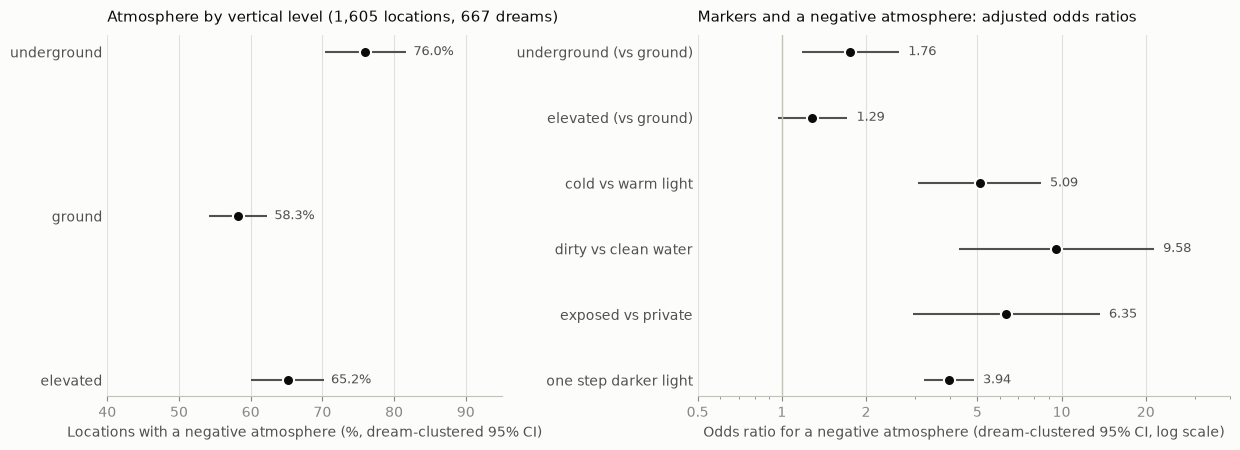

In [12]:
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
plt.rcParams.update({"figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": AXIS, "axes.labelcolor": INK2,
                     "xtick.color": MUTED, "ytick.color": INK2, "text.color": INK, "axes.grid": False, "font.size": 10})
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), gridspec_kw={"width_ratios": [1, 1.35]})
ax = axes[0]
tab = rate_by(V, "level_cat", "neg", ["underground", "ground", "elevated"])
los = tab["95% CI"].str.split("–").str[0].astype(float); his = tab["95% CI"].str.split("–").str[1].astype(float)
y = np.arange(3)[::-1]
ax.hlines(y, los, his, color=INK2, lw=1.5)
ax.plot(tab["%"], y, "o", ms=8, color=INK, mec=SURFACE, mew=1.5, zorder=3)
for yi, v_, h_ in zip(y, tab["%"], his):
    ax.text(h_ + 1, yi, f"{v_:.1f}%", va="center", fontsize=9, color=INK2)
ax.set_yticks(y, ["underground", "ground", "elevated"]); ax.tick_params(axis="y", length=0)
ax.set_xlim(40, 95); ax.set_xlabel("Locations with a negative atmosphere (%, dream-clustered 95% CI)")
ax.xaxis.grid(True, color=GRID, lw=0.8); ax.set_axisbelow(True)
for s_ in ("top", "right", "left"): ax.spines[s_].set_visible(False)
ax.set_title("Atmosphere by vertical level (1,605 locations, 667 dreams)", loc="left", color=INK, fontsize=11, pad=10)

ax = axes[1]
rows = [("underground (vs ground)", models["E: D + location type"], "under"),
        ("elevated (vs ground)", models["E: D + location type"], "elev"),
        ("cold vs warm light", clogit(lta, "neg ~ cold + log_words + C(type_c)"), "cold"),
        ("dirty vs clean water", res4, "dirty"),
        ("exposed vs private", clogit(pa, "neg ~ exposed_ + log_words"), "exposed_"),
        ("one step darker light", clogit(lq, "neg ~ light_rank + log_words + C(type_c)"), "light_rank")]
y = np.arange(len(rows))[::-1]
for yi, (lab, res_, term) in zip(y, rows):
    t = mw.odds_ratio_table(res_, [term]).iloc[0]
    ax.hlines(yi, t.lo, t.hi, color=INK2, lw=1.5)
    ax.plot(t.OR, yi, "o", ms=8, color=INK, mec=SURFACE, mew=1.5, zorder=3)
    ax.text(t.hi * 1.08, yi, f"{t.OR:.2f}", va="center", fontsize=9, color=INK2)
ax.axvline(1, color=AXIS, lw=1)
ax.set_xscale("log"); ax.set_xlim(0.5, 40)
ax.set_xticks([0.5, 1, 2, 5, 10, 20], ["0.5", "1", "2", "5", "10", "20"])
ax.set_yticks(y, [r[0] for r in rows]); ax.tick_params(axis="y", length=0)
ax.set_xlabel("Odds ratio for a negative atmosphere (dream-clustered 95% CI, log scale)")
ax.xaxis.grid(True, color=GRID, lw=0.8); ax.set_axisbelow(True)
for s_ in ("top", "right", "left"): ax.spines[s_].set_visible(False)
ax.set_title("Markers and a negative atmosphere: adjusted odds ratios", loc="left", color=INK, fontsize=11, pad=10)
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "02_spatial_affective.png", dpi=150, bbox_inches="tight"); plt.show()

## Summary table

In [13]:
print("See the findings cells; this cell lists the corrected headline numbers for the report.")
print(f"C1 rho(level, valence) = {rho_v:+.3f} [{lo_v:+.3f}, {hi_v:+.3f}]")

See the findings cells; this cell lists the corrected headline numbers for the report.
C1 rho(level, valence) = +0.064 [+0.007, +0.114]
